# EWC Replication — Kirkpatrick et al. 2017 (Fig 2A/2B/2C)

A faithful recreation of the paper's EWC, with the fixes that stop Fig 2B collapsing.

Background — the two failure modes you saw:

- `fixed_1_4_2`: under-estimated (batch-averaged) Fisher → Fig 2B average fell to ~0.8.
- `FIXED_2`: correct Fisher, but **a stiff lambda + grad clipping + limited capacity** over-constrained the
  network so it could not learn new tasks → Fig 2B average fell to ~0.7.

**What changed here**

1. **Correct per-sample Fisher** (kept from `FIXED_2`): one example at a time, label sampled from the model's own
   predictive distribution. This is the true Fisher (the Laplace approximation in Section 2).
2. **Paper-exact penalty (equation 3).** A **separate** Fisher and anchor are stored for **each** task and summed:
   `L = L_B + sum_tasks sum_i (lambda/2) F_i (theta_i - theta*_i)^2`. This is the paper's "separate penalties"
   scheme — not the online-EWC variant.
3. **No gradient clipping** on the EWC model — the clip in `FIXED_2` was suppressing the consolidation force.
4. **Wider network** (default 1200; the paper's Fig 2B column allowed up to 2000).
5. Dedicated single-task reference model (correct dashed line), and SGD+dropout baseline with per-task early stopping.

> Note: lambda and the Fisher scale are coupled, so the lambda values from your old notebooks do **not** transfer.
> With summed per-task penalties the total constraint grows as tasks accumulate, so set `LAMBDA` in the config below
> and check one value at a time.

> Target: a red EWC line that is **flat and just under the single-task reference** (~0.93-0.96 in this setup).
> Aiming for *exactly* 0.90 usually means over-constraining; let the tuned lambda find its natural level.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import copy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Configuration

All knobs live here. Start with the defaults; the notes say what to change if a run misbehaves.

In [2]:
# ----------------------------- CONFIG -----------------------------
NUM_TASKS        = 10
WIDTH            = 2000     # paper: Fig 2A=400, Fig 2B allowed up to 2000. Wider = more capacity for EWC.
EPOCHS_PER_TASK  = 20       # paper used up to 100 for Fig 2B. Raise toward 40-100 if the line still droops.
LR               = 1e-3     # if a run diverges (NaNs / sudden collapse), lower to 5e-4 instead of clipping.
MOMENTUM         = 0.9
BATCH_SIZE       = 256

# --- EWC (paper-exact: separate Fisher + anchor per task, summed) ---
FISHER_SAMPLES   = 2048     # per-sample Fisher estimate size. Higher = lower variance, slower.
NORMALIZE_PENALTY = True    # NOTE: currently fixed to True in train_ewc_sequence; changing this has no effect unless wired in

# --- EWC penalty strength ---
# lambda and Fisher scale are coupled; old-notebook values do NOT transfer. Check one value at a time.
# Try a few across ~2 orders of magnitude (e.g. 50, 150, 500, 1500, 5000) and keep the flattest, highest curve.
LAMBDA           = 100

# --- baselines ---
L2_LAMBDA           = 1.0   # uniform quadratic penalty for the L2 control (Fig 2A green)
EARLY_STOP_PATIENCE = 5     # paper: stop after 5 steps of rising validation error (SGD+dropout)

SEED             = 0
# ------------------------------------------------------------------
print('Config loaded.')

Config loaded.


## Data — Permuted MNIST

Task 0 is the original MNIST; tasks 1..9 each apply a fixed random pixel permutation. A 10k validation split is
held out for the dropout baseline's early stopping.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

full_train = datasets.MNIST('./data', train=True,  download=True, transform=transform)
full_test  = datasets.MNIST('./data', train=False, download=True, transform=transform)

val_size   = 10000
train_size = len(full_train) - val_size
train_base, val_base = torch.utils.data.random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)

class PermutedMNIST(torch.utils.data.Dataset):
    def __init__(self, dataset, permutation=None):
        self.dataset     = dataset
        self.permutation = permutation
    def __len__(self):
        return len(self.dataset)
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        if self.permutation is not None:
            img = img.view(-1)[self.permutation].view(1, 28, 28)
        return img, label

torch.manual_seed(42)
tasks = {}
for i in range(NUM_TASKS):
    perm = None if i == 0 else torch.randperm(28 * 28)
    tasks[i] = {
        'train': DataLoader(PermutedMNIST(train_base, perm), batch_size=BATCH_SIZE, shuffle=True),
        'val':   DataLoader(PermutedMNIST(val_base,   perm), batch_size=1000,       shuffle=False),
        'test':  DataLoader(PermutedMNIST(full_test,  perm), batch_size=1000,       shuffle=False),
        'perm':  perm,
    }
print(f'Permuted MNIST ready for {NUM_TASKS} tasks.')

Permuted MNIST ready for 10 tasks.


## Models

In [4]:
class Net(nn.Module):
    """2 hidden layers, configurable width."""
    def __init__(self, width=400):
        super().__init__()
        self.fc1 = nn.Linear(784, width)
        self.fc2 = nn.Linear(width, width)
        self.fc3 = nn.Linear(width, 10)
    def forward(self, x):
        x = x.view(-1, 784)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


class NetDropout(nn.Module):
    """Same architecture + dropout (0.2 input, 0.5 hidden) for the SGD+dropout baseline."""
    def __init__(self, width=400):
        super().__init__()
        self.drop_in = nn.Dropout(0.2)
        self.fc1     = nn.Linear(784, width)
        self.drop_h  = nn.Dropout(0.5)
        self.fc2     = nn.Linear(width, width)
        self.fc3     = nn.Linear(width, 10)
    def forward(self, x):
        x = x.view(-1, 784)
        x = self.drop_in(x)
        x = F.relu(self.fc1(x))
        x = self.drop_h(x)
        x = F.relu(self.fc2(x))
        x = self.drop_h(x)
        return self.fc3(x)

print('Models ready.')

Models ready.


## EWC helpers

`compute_fisher` is the **correct** per-sample Fisher: it feeds one example at a time and samples the label from the
model's own predictive distribution, so each `grad**2` is a genuine per-sample contribution (no 1/batch_size
under-estimate).

In [5]:
def compute_fisher(model, data_loader, num_samples=1024):
    """True diagonal Fisher: E[(d log p / d theta)^2], estimated per-sample."""
    fisher = {n: torch.zeros_like(p) for n, p in model.named_parameters()}
    model.eval()
    seen = 0
    for data, _ in data_loader:
        data = data.to(device)
        for x in data:
            if seen >= num_samples:
                break
            x = x.unsqueeze(0)
            model.zero_grad()
            logits = model(x)
            log_p  = F.log_softmax(logits, dim=1)
            p      = F.softmax(logits, dim=1).clamp_min(1e-8)
            p      = p / p.sum(dim=1, keepdim=True)
            y      = torch.multinomial(p, 1).squeeze(1)   # sample from model's own distribution
            loss   = F.nll_loss(log_p, y)
            loss.backward()
            for n, par in model.named_parameters():
                if par.grad is not None:
                    fisher[n] += par.grad.detach() ** 2
            seen += 1
        if seen >= num_samples:
            break
    for n in fisher:
        fisher[n] /= max(seen, 1)
    model.zero_grad()
    return fisher


def ewc_penalty_multi(model, ewc_tasks, normalize=True):
    penalty = 0.0
    for task in ewc_tasks:
        fisher = task['fisher']
        anchor = task['anchor']
        for n, p in model.named_parameters():
            penalty += (fisher[n] * (p - anchor[n]) ** 2).sum()
    if normalize and len(ewc_tasks) > 0:
        penalty = penalty / len(ewc_tasks)
    return penalty


def test_model(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            correct += model(data).argmax(dim=1).eq(target).sum().item()
    return correct / len(loader.dataset)


def avg_val_acc(model, loaders):
    return float(np.mean([test_model(model, ldr) for ldr in loaders]))

print('Helpers ready.')

Helpers ready.


## EWC training loop (paper-exact)

After each task we store that task's Fisher and its anchor (the weights at that task's end) in a list, and the
penalty sums over every stored task — exactly the paper's separate-penalties form of equation 3.
`record_history=True` records per-epoch test accuracy for Fig 2A.

In [6]:
def train_ewc_sequence(lamda, width=WIDTH, epochs=EPOCHS_PER_TASK,
                       lr=LR, fisher_samples=FISHER_SAMPLES, seed=SEED,
                       record_history=False, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = Net(width).to(device)
    opt   = optim.SGD(model.parameters(), lr=lr, momentum=MOMENTUM)

    ewc_tasks = []   # one {'fisher':..., 'anchor':...} per completed task (paper: separate penalties)
    history   = {i: [] for i in range(NUM_TASKS)}
    snapshots = []   # end-of-task average over all tasks seen so far (x = 2..NUM_TASKS)

    for task_id in range(NUM_TASKS):
        train_loader = tasks[task_id]['train']
        for epoch in range(epochs):
            model.train()
            for data, target in train_loader:
                data, target = data.to(device), target.to(device)
                opt.zero_grad()
                loss = F.cross_entropy(model(data), target)
                if ewc_tasks:
                    loss = loss + (lamda / 2.0) * ewc_penalty_multi(model, ewc_tasks, normalize=NORMALIZE_PENALTY)
                loss.backward()
                opt.step()   # no gradient clipping — clipping suppressed EWC consolidation in FIXED_2
            if record_history:
                for tid in range(NUM_TASKS):
                    history[tid].append(test_model(model, tasks[tid]['test']))

        # ---- consolidate: store this task's own Fisher + anchor ----
        new_fisher = compute_fisher(model, train_loader, fisher_samples)
        new_anchor = {n: p.detach().clone() for n, p in model.named_parameters()}
        ewc_tasks.append({'fisher': new_fisher, 'anchor': new_anchor})

        if task_id >= 1:
            seen = list(range(task_id + 1))
            snapshots.append(float(np.mean([test_model(model, tasks[t]['test']) for t in seen])))

        if verbose:
            cur  = test_model(model, tasks[task_id]['test'])
            prev = (float(np.mean([test_model(model, tasks[t]['test']) for t in range(task_id)]))
                    if task_id > 0 else float('nan'))
            print(f'  task {task_id + 1:2d}/{NUM_TASKS}: current={cur:.3f}  prev_avg={prev:.3f}')

    return {'snapshots': snapshots, 'history': history, 'model': model}

print('Training loop ready.')

Training loop ready.


## Single-task reference (the dashed line)

A network trained only on Task 0 — the correct reference, independent of the EWC run.

In [7]:
torch.manual_seed(99)
model_single = Net(WIDTH).to(device)
opt_single   = optim.SGD(model_single.parameters(), lr=LR, momentum=MOMENTUM)

print('Training single-task reference on Task 0 only...')
for ep in range(EPOCHS_PER_TASK):
    model_single.train()
    for data, target in tasks[0]['train']:
        data, target = data.to(device), target.to(device)
        opt_single.zero_grad()
        F.cross_entropy(model_single(data), target).backward()
        opt_single.step()

single_task_perf = test_model(model_single, tasks[0]['test'])
print(f'Single-task performance (Task 0 test acc): {single_task_perf:.4f}')

Training single-task reference on Task 0 only...
Single-task performance (Task 0 test acc): 0.9535


## EWC run

Trains the EWC model once at the `LAMBDA` you set in the config, recording per-epoch history (for Fig 2A) and
end-of-task averages (for Fig 2B). To check a different value, change `LAMBDA` above and re-run from here.

In [8]:
print(f'Training EWC at lambda = {LAMBDA} ...')
ewc_run       = train_ewc_sequence(LAMBDA, record_history=True, verbose=True)
history_ewc   = ewc_run['history']
ewc_snapshots = ewc_run['snapshots']

print('\nEWC averages (tasks 2..%d):' % NUM_TASKS, [f'{v:.3f}' for v in ewc_snapshots])
print(f'EWC drop first->last: {ewc_snapshots[0] - ewc_snapshots[-1]:+.3f}')
print(f'Single-task ref:      {single_task_perf:.3f}')

Training EWC at lambda = 100 ...
  task  1/10: current=0.954  prev_avg=nan
  task  2/10: current=0.960  prev_avg=0.943
  task  3/10: current=0.964  prev_avg=0.942
  task  4/10: current=0.964  prev_avg=0.929
  task  5/10: current=0.967  prev_avg=0.934
  task  6/10: current=0.966  prev_avg=0.933
  task  7/10: current=0.967  prev_avg=0.916
  task  8/10: current=0.968  prev_avg=0.895
  task  9/10: current=0.967  prev_avg=0.899
  task 10/10: current=0.970  prev_avg=0.877

EWC averages (tasks 2..10): ['0.952', '0.949', '0.938', '0.941', '0.938', '0.923', '0.904', '0.907', '0.886']
EWC drop first->last: +0.066
Single-task ref:      0.954


## Baselines for the figures

SGD (Fig 2A blue), L2 uniform-penalty control (Fig 2A green), and SGD+dropout with per-task early stopping
(Fig 2B blue). Trained once.

In [9]:
def train_baselines(width=WIDTH, epochs=EPOCHS_PER_TASK, lr=LR,
                    l2_lambda=L2_LAMBDA, patience=EARLY_STOP_PATIENCE, seed=SEED):
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    m_sgd  = Net(width).to(device)
    m_l2   = Net(width).to(device)
    m_drop = NetDropout(width).to(device)
    o_sgd  = optim.SGD(m_sgd.parameters(),  lr=lr, momentum=MOMENTUM)
    o_l2   = optim.SGD(m_l2.parameters(),   lr=lr, momentum=MOMENTUM)
    o_drop = optim.SGD(m_drop.parameters(), lr=lr, momentum=MOMENTUM)

    l2_anchor = None
    h_sgd  = {i: [] for i in range(NUM_TASKS)}
    h_l2   = {i: [] for i in range(NUM_TASKS)}
    h_drop = {i: [] for i in range(NUM_TASKS)}
    drop_snaps = []

    for task_id in range(NUM_TASKS):
        print(f'  baselines: task {task_id + 1}/{NUM_TASKS}')
        train_loader = tasks[task_id]['train']
        val_loaders  = [tasks[t]['val'] for t in range(task_id + 1)]

        best_val   = -1.0
        best_state = copy.deepcopy(m_drop.state_dict())
        no_improve = 0
        stopped    = False

        for epoch in range(epochs):
            m_sgd.train(); m_l2.train(); m_drop.train()
            for data, target in train_loader:
                data, target = data.to(device), target.to(device)

                o_sgd.zero_grad()
                F.cross_entropy(m_sgd(data), target).backward()
                o_sgd.step()

                o_l2.zero_grad()
                loss_l2 = F.cross_entropy(m_l2(data), target)
                if l2_anchor is not None:
                    pen = sum(((p - l2_anchor[n]) ** 2).sum() for n, p in m_l2.named_parameters())
                    loss_l2 = loss_l2 + (l2_lambda / 2.0) * pen
                loss_l2.backward()
                o_l2.step()

                if not stopped:
                    o_drop.zero_grad()
                    F.cross_entropy(m_drop(data), target).backward()
                    o_drop.step()

            for tid in range(NUM_TASKS):
                h_sgd[tid].append( test_model(m_sgd,  tasks[tid]['test']))
                h_l2[tid].append(  test_model(m_l2,   tasks[tid]['test']))
                h_drop[tid].append(test_model(m_drop, tasks[tid]['test']))

            if not stopped:
                val_avg = avg_val_acc(m_drop, val_loaders)
                if val_avg > best_val:
                    best_val = val_avg
                    best_state = copy.deepcopy(m_drop.state_dict())
                    no_improve = 0
                else:
                    no_improve += 1
                    if no_improve >= patience:
                        m_drop.load_state_dict(best_state)
                        stopped = True
        if not stopped:
            m_drop.load_state_dict(best_state)

        l2_anchor = {n: p.detach().clone() for n, p in m_l2.named_parameters()}

        if task_id >= 1:
            seen = list(range(task_id + 1))
            drop_snaps.append(float(np.mean([test_model(m_drop, tasks[t]['test']) for t in seen])))

    return {'sgd': h_sgd, 'l2': h_l2, 'dropout': h_drop, 'dropout_snapshots': drop_snaps}

print('Training baselines...')
bl = train_baselines()
history_sgd       = bl['sgd']
history_l2        = bl['l2']
history_dropout   = bl['dropout']
dropout_snapshots = bl['dropout_snapshots']
print('Baselines done.')

Training baselines...
  baselines: task 1/10
  baselines: task 2/10
  baselines: task 3/10
  baselines: task 4/10
  baselines: task 5/10
  baselines: task 6/10
  baselines: task 7/10
  baselines: task 8/10
  baselines: task 9/10
  baselines: task 10/10
Baselines done.


## Figure 2A — Training curves for Tasks A, B, C

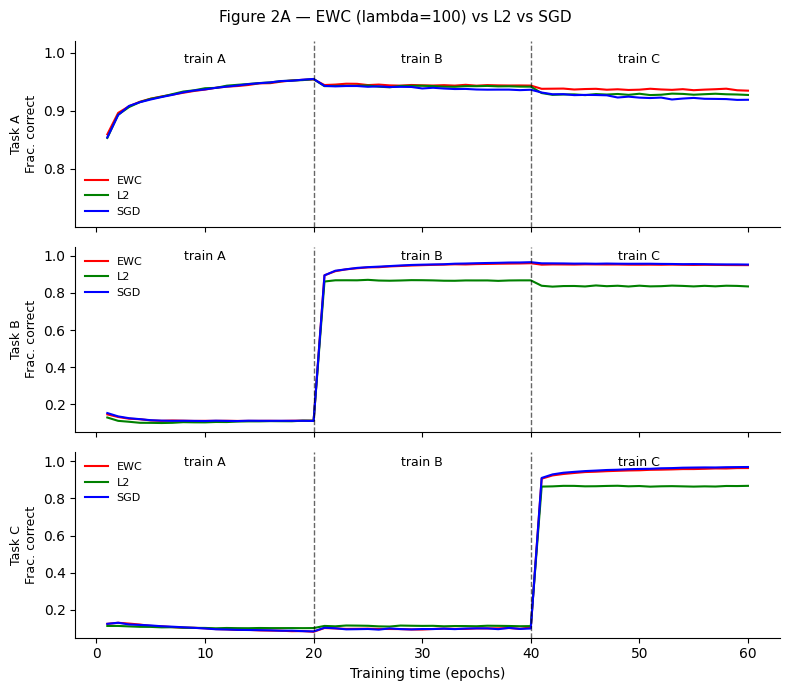

In [10]:
epochs_to_show = 3 * EPOCHS_PER_TASK
x = range(1, epochs_to_show + 1)

fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
for ax, tid, label in zip(axes, [0, 1, 2], ['Task A', 'Task B', 'Task C']):
    ax.plot(x, history_ewc[tid][:epochs_to_show], color='red',   label='EWC', linewidth=1.5)
    ax.plot(x, history_l2[tid][:epochs_to_show],  color='green', label='L2',  linewidth=1.5)
    ax.plot(x, history_sgd[tid][:epochs_to_show], color='blue',  label='SGD', linewidth=1.5)
    for i in range(1, 3):
        ax.axvline(x=EPOCHS_PER_TASK * i, color='black', linestyle='--', alpha=0.6, linewidth=1.0)
    ax.set_ylabel(f'{label}\nFrac. correct', fontsize=9)
    if tid == 0:
        ax.set_ylim([0.70, 1.02]); ax.set_yticks([0.8, 0.9, 1.0])
    else:
        ax.set_ylim([0.05, 1.05]); ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.legend(loc='lower left' if tid == 0 else 'upper left', fontsize=8, frameon=False)
    for i in range(3):
        mid = EPOCHS_PER_TASK * i + EPOCHS_PER_TASK // 2
        ax.text(mid, ax.get_ylim()[1] * 0.98, f'train {chr(65 + i)}', ha='center', va='top', fontsize=9)

axes[-1].set_xlabel('Training time (epochs)', fontsize=10)
fig.suptitle(f'Figure 2A — EWC (lambda={LAMBDA}) vs L2 vs SGD', fontsize=11)
plt.tight_layout(); plt.savefig('fig2A.png', dpi=150, bbox_inches='tight'); plt.show()

## Figure 2B — Average performance across all tasks seen so far

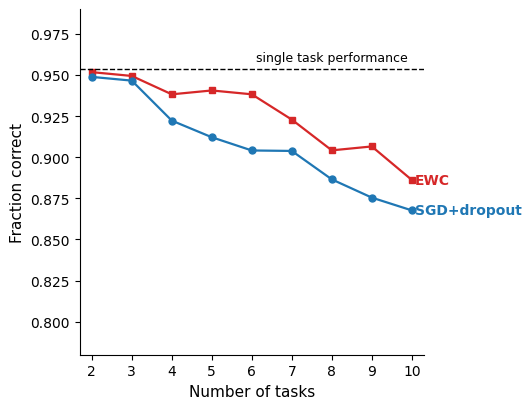

EWC averages:     ['0.952', '0.949', '0.938', '0.941', '0.938', '0.923', '0.904', '0.907', '0.886']
Dropout averages: ['0.949', '0.947', '0.922', '0.912', '0.904', '0.904', '0.886', '0.875', '0.868']
Single-task ref: 0.954
EWC drop first->last: +0.066


In [11]:
x_tasks = list(range(2, NUM_TASKS + 1))

fig, ax = plt.subplots(figsize=(5.4, 4.2))
ax.plot(x_tasks, ewc_snapshots,     color='#d62728', marker='s', markersize=5, linewidth=1.6, label='EWC')
ax.plot(x_tasks, dropout_snapshots, color='#1f77b4', marker='o', markersize=5, linewidth=1.6, label='SGD+dropout')
ax.axhline(y=single_task_perf, color='black', linestyle='--', linewidth=1.0)
ax.text(NUM_TASKS - 0.1, single_task_perf + 0.003, 'single task performance',
        ha='right', va='bottom', fontsize=9)

ax.set_xlabel('Number of tasks', fontsize=11); ax.set_ylabel('Fraction correct', fontsize=11)
ax.set_xticks(x_tasks); ax.set_xlim(1.7, NUM_TASKS + 0.3)
y_lo = min(0.78, min(dropout_snapshots) - 0.02)
y_hi = max(0.99, max(ewc_snapshots) + 0.01, single_task_perf + 0.015)
ax.set_ylim(y_lo, y_hi)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.text(x_tasks[-1] + 0.08, ewc_snapshots[-1],     'EWC',         color='#d62728', fontsize=10, va='center', fontweight='bold')
ax.text(x_tasks[-1] + 0.08, dropout_snapshots[-1], 'SGD+dropout', color='#1f77b4', fontsize=10, va='center', fontweight='bold')
plt.tight_layout(); plt.savefig('fig2B.png', dpi=150, bbox_inches='tight'); plt.show()

print('EWC averages:    ', [f'{v:.3f}' for v in ewc_snapshots])
print('Dropout averages:', [f'{v:.3f}' for v in dropout_snapshots])
print(f'Single-task ref: {single_task_perf:.3f}')
print(f'EWC drop first->last: {ewc_snapshots[0] - ewc_snapshots[-1]:+.3f}')

## Figure 2C — Fisher overlap vs layer depth

Unchanged from your `FIXED_2` notebook (the global-normalisation version). A 6-hidden-layer network is trained
sequentially on a base task then a partially-permuted task; we measure per-layer overlap between the two Fisher
matrices. Low permutation (8x8 patch) -> high overlap everywhere; high permutation (26x26) -> low overlap in early
layers rising toward the shared output.

> Independent of Fig 2A/2B — it trains its own networks and does not use `LAMBDA`. It is also the slowest cell
> (100 epochs x 2 tasks x 2 pairs); lower `FIG2C_EPOCHS` if you just want the shape.

In [12]:
FIG2C_EPOCHS = 100   # paper Table 1 (Fig 2C column). Lower for a quicker run.

class NetDeep(nn.Module):
    """6 hidden layers (fc1-fc6) x 100 units + output layer (fc7 -> 10 classes). Used for Fig 2C Fisher overlap."""
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 100)
        self.fc2 = nn.Linear(100, 100)
        self.fc3 = nn.Linear(100, 100)
        self.fc4 = nn.Linear(100, 100)
        self.fc5 = nn.Linear(100, 100)
        self.fc6 = nn.Linear(100, 100)
        self.fc7 = nn.Linear(100, 10)
    def forward(self, x):
        x = x.view(-1, 784)
        x = F.relu(self.fc1(x)); x = F.relu(self.fc2(x)); x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x)); x = F.relu(self.fc5(x)); x = F.relu(self.fc6(x))
        return self.fc7(x)


def create_partial_permutation(size):
    """Permute only a (size x size) square centred in the 28x28 image."""
    perm = torch.arange(28 * 28)
    grid = perm.view(28, 28).clone()
    start = (28 - size) // 2
    end   = start + size
    region   = grid[start:end, start:end].flatten()
    shuffled = region[torch.randperm(len(region))]
    grid[start:end, start:end] = shuffled.view(size, size)
    return grid.flatten()


def fisher_to_global_vector(fisher_dict, layer_names):
    """Concatenate all weight+bias Fisher values into one flat global vector."""
    parts = []
    for name in layer_names:
        parts.append(fisher_dict[name + '.weight'].flatten().clamp(min=0))
        parts.append(fisher_dict[name + '.bias'].flatten().clamp(min=0))
    return torch.cat(parts)


def calculate_overlap_correct(fisher_A, fisher_B, layer_names):
    """Per-layer Fisher overlap using GLOBALLY normalised Fisher vectors (Kirkpatrick et al. 2017, Appendix 4.3)."""
    v_A = fisher_to_global_vector(fisher_A, layer_names)
    v_B = fisher_to_global_vector(fisher_B, layer_names)
    v_A = v_A / (v_A.sum() + 1e-10)
    v_B = v_B / (v_B.sum() + 1e-10)
    overlaps = []
    idx = 0
    for name in layer_names:
        n  = fisher_A[name + '.weight'].numel() + fisher_A[name + '.bias'].numel()
        sA = v_A[idx: idx + n]
        sB = v_B[idx: idx + n]
        idx += n
        d2 = 0.5 * torch.sum((torch.sqrt(sA) - torch.sqrt(sB)) ** 2).item()
        overlaps.append(max(0.0, 1.0 - d2))
    return overlaps

print('Fig 2C helpers ready.')

Fig 2C helpers ready.


In [13]:
torch.manual_seed(7)
layer_names = ['fc1', 'fc2', 'fc3', 'fc4', 'fc5', 'fc6']

perm_base = None                            # original MNIST (task A for both pairs)
perm_low  = create_partial_permutation(8)   # 8x8  patch ~8%  permuted (similar tasks)
perm_high = create_partial_permutation(26)  # 26x26 patch ~86% permuted (dissimilar tasks)

loader_base = DataLoader(PermutedMNIST(full_train, perm_base), batch_size=256, shuffle=True)
loader_low  = DataLoader(PermutedMNIST(full_train, perm_low),  batch_size=256, shuffle=True)
loader_high = DataLoader(PermutedMNIST(full_train, perm_high), batch_size=256, shuffle=True)

def train_sequential(loader_A, loader_B, epochs=FIG2C_EPOCHS):
    """Train a fresh NetDeep on task A then task B, return both Fishers."""
    model = NetDeep().to(device)
    opt   = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
    model.train()
    for ep in range(epochs):
        for data, target in loader_A:
            data, target = data.to(device), target.to(device)
            opt.zero_grad(); F.cross_entropy(model(data), target).backward(); opt.step()
        if (ep + 1) % 20 == 0: print(f'  task-A epoch {ep+1}')
    fisher_A = compute_fisher(model, loader_A, num_samples=8192)
    for ep in range(epochs):
        for data, target in loader_B:
            data, target = data.to(device), target.to(device)
            opt.zero_grad(); F.cross_entropy(model(data), target).backward(); opt.step()
        if (ep + 1) % 20 == 0: print(f'  task-B epoch {ep+1}')
    fisher_B = compute_fisher(model, loader_B, num_samples=8192)
    return fisher_A, fisher_B

print('Training LOW permutation pair (8x8)...')
fisher_A_low,  fisher_B_low  = train_sequential(loader_base, loader_low)
print('\nTraining HIGH permutation pair (26x26)...')
fisher_A_high, fisher_B_high = train_sequential(loader_base, loader_high)
print('\nDone.')

Training LOW permutation pair (8x8)...
  task-A epoch 20
  task-A epoch 40
  task-A epoch 60
  task-A epoch 80
  task-A epoch 100
  task-B epoch 20
  task-B epoch 40
  task-B epoch 60
  task-B epoch 80
  task-B epoch 100

Training HIGH permutation pair (26x26)...
  task-A epoch 20
  task-A epoch 40
  task-A epoch 60
  task-A epoch 80
  task-A epoch 100
  task-B epoch 20
  task-B epoch 40
  task-B epoch 60
  task-B epoch 80
  task-B epoch 100

Done.


Overlap (low  8x8  permutation): ['0.754', '0.981', '0.997', '0.999', '0.999', '0.999']
Overlap (high 26x26 permutation): ['0.541', '0.901', '0.979', '0.996', '0.998', '0.998']


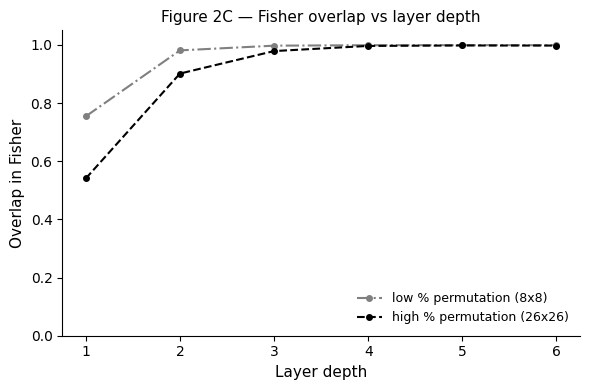

In [14]:
overlap_low  = calculate_overlap_correct(fisher_A_low,  fisher_B_low,  layer_names)
overlap_high = calculate_overlap_correct(fisher_A_high, fisher_B_high, layer_names)

print('Overlap (low  8x8  permutation):', [f'{v:.3f}' for v in overlap_low])
print('Overlap (high 26x26 permutation):', [f'{v:.3f}' for v in overlap_high])

fig, ax = plt.subplots(figsize=(6, 4))
x_layers = range(1, len(layer_names) + 1)
ax.plot(x_layers, overlap_low,  color='grey',  linestyle='-.', marker='.', markersize=8,
        linewidth=1.5, label='low % permutation (8x8)')
ax.plot(x_layers, overlap_high, color='black', linestyle='--', marker='.', markersize=8,
        linewidth=1.5, label='high % permutation (26x26)')
ax.set_xlabel('Layer depth', fontsize=11); ax.set_ylabel('Overlap in Fisher', fontsize=11)
ax.set_xticks(list(x_layers)); ax.set_ylim([0, 1.05])
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(loc='lower right', fontsize=9, frameon=False)
ax.set_title('Figure 2C — Fisher overlap vs layer depth', fontsize=11)
plt.tight_layout(); plt.savefig('fig2C.png', dpi=150, bbox_inches='tight'); plt.show()

## If the red line still droops

In rough order of impact:

1. **Try other `LAMBDA` values.** Change `LAMBDA` in the config and re-run from the EWC-run cell. Move across
   ~2 orders of magnitude (e.g. 50, 150, 500, 1500, 5000) and keep the flattest, highest curve. If your best value
   sits at an extreme, push further in that direction.
2. **More capacity / longer training.** Raise `WIDTH` toward 2000 and `EPOCHS_PER_TASK` toward 40-100 (paper's 2B recipe).
3. **Lower the learning rate** (e.g. 5e-4). With many summed penalties the loss surface gets stiff; a smaller step
   is often more stable than fighting it, and avoids any need for gradient clipping.
4. **More Fisher samples.** Raise `FISHER_SAMPLES` for a lower-variance importance estimate.
5. **Average over seeds.** Re-run `train_ewc_sequence(LAMBDA, seed=...)` for a few seeds and average the snapshots;
   single-seed curves dip noisily.
